In [1]:
%load_ext watermark

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tcspc_sim import SimSample, SimFalcon, PhasorPlot
%watermark -v -p matplotlib,numpy

Python implementation: CPython
Python version       : 3.9.2
IPython version      : 7.21.0

matplotlib: 3.3.4
numpy     : 1.20.1



In [3]:
lifetimes = [4.0, 4.0, 6.0, 1.0]
fractions = [50, 50, 5, 5]
fractionnames = ['Epac bound', 'Epac unbound', 'AF long', 'AF short']
simSample = SimSample(lifetimes, fractions, fractionnames)
print(simSample)

Sample contains the following lifetimes:
  * Epac bound : 4.00ns - 45.45% of photons
  * Epac unbound : 4.00ns - 45.45% of photons
  * AF long : 6.00ns - 4.55% of photons
  * AF short : 1.00ns - 4.55% of photons


In [4]:
qv = [0.15, 0.525,0, 0]
simSample.set_quenching(qv)
print(simSample)

Sample contains the following lifetimes:
  * Epac bound : 3.40ns - 55.74% of photons
  * Epac unbound : 1.90ns - 31.15% of photons
  * AF long : 6.00ns - 6.56% of photons
  * AF short : 1.00ns - 6.56% of photons


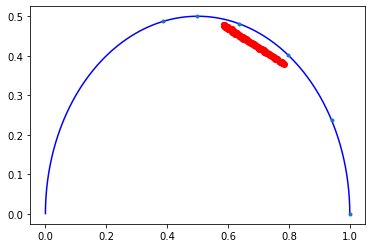

In [5]:
fraction = np.linspace(0,100,101)
simFalcon = SimFalcon([0])
x_coords = []
y_coords = []
for f in fraction:
    fractions = [f, 100-f, 5, 5]
    simSample.set_fraction(fractions, qv)
    photons,npht = simSample.generate_photons(1e5)
    simFalcon.setphotons(photons)
    x,y = simFalcon.getphasorcoordinates()
    x_coords.append(x)
    y_coords.append(y)

phasorPlot = PhasorPlot(simFalcon.getomega(),np.array([0,1,2,3,4,5]))
phasorPlot.plot(x_coords,y_coords)